# Heart Disease Classification — Project Proposal

**Dataset:** UCI Heart Disease (Cleveland), 303 records, 14 attributes
**Source:** https://archive.ics.uci.edu/dataset/45/heart+disease

## Why this dataset

A compact, well-documented clinical dataset that supports the full range of course techniques: descriptive stats and distribution fitting on the continuous predictors, hypothesis tests and CIs comparing patient groups, Bayesian reasoning about diagnostic probability, logistic regression on a binary target, and classification metrics (AUROC, sensitivity, specificity) with natural clinical meaning.

## Target

The raw `num` field is 0–4 (severity). Following standard practice, we collapse to a binary target: `0` = no disease, `1` = disease present.

## Notes

- 6 records have missing values in `ca` and `thal` (encoded as `?`) — needs a documented cleaning decision.
- Mix of continuous (age, trestbps, chol, thalach, oldpeak) and categorical (sex, cp, fbs, restecg, exang, slope, ca, thal) features.

This notebook is a first pass — load, inspect, summary stats. EDA and modeling come after team alignment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import logit

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, accuracy_score
)

np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

## Initial inspection

**Size and missing stuff.** 303 records × 15 columns (14 original attributes + the engineered `target`). Missing values are minimal, 4 in `ca` and 2 in `thal`, totaling 6 of 303 (~2%). Small enough to drop or get rid of with little impact, but the decision will need to be documented.

**Class balance.** 164 patients without disease (54%) vs. 139 with disease (46%) — close to balanced.

**Continuous predictors look reasonable.** Age spans 29–77 (mean 54). Resting BP (`trestbps`) and cholesterol (`chol`) sit in clinically plausible ranges, though `chol` has a max of 564 — worth checking as a potential outlier in EDA. Max heart rate (`thalach`) ranges 71–202, and ST depression (`oldpeak`) is right-skewed (median 0.8, max 6.2).

**Categorical predictors are integer-encoded.** `sex`, `cp` (chest pain type, 1–4), `fbs`, `restecg`, `exang`, `slope`, `ca`, and `thal` are stored as numeric codes and will need to be treated as categorical in modeling — not used as continuous predictors despite their dtype.

**Takeaway.** The dataset is clean, compact, and well-structured. The natural next steps are visualizing the target relationship with key predictors and deciding on our modeling strategy.

In [2]:
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"
]

# `?` marks missing values in the raw file
heart = pd.read_csv(URL, header=None, names=columns, na_values="?")

# Collapse the 0-4 severity target to a binary indicator (standard practice in the literature)
heart["target"] = (heart["num"] > 0).astype(int)

print(f"Shape: {heart.shape}")
print(f"Missing values per column:\n{heart.isna().sum()[heart.isna().sum() > 0]}\n")
print(f"Target class balance:\n{heart['target'].value_counts()}\n")

heart.head()

Shape: (303, 15)
Missing values per column:
ca      4
thal    2
dtype: int64

Target class balance:
target
0    164
1    139
Name: count, dtype: int64



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


In [3]:
heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000


## Data cleaning

Drop the 6 rows with missing values and convert the integer-coded categorical variables to `category` dtype so they're handled correctly in plots and models.

In [4]:
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

heart_clean = heart.dropna().copy()
heart_clean[categorical_cols] = heart_clean[categorical_cols].astype("category")

print(f"Shape after cleaning: {heart_clean.shape}")
print(f"Rows dropped: {len(heart) - len(heart_clean)}")
heart_clean.dtypes

Shape after cleaning: (297, 15)
Rows dropped: 6


age          float64
sex         category
cp          category
trestbps     float64
chol         float64
fbs         category
restecg     category
thalach      float64
exang       category
oldpeak      float64
slope       category
ca          category
thal        category
num            int64
target         int64
dtype: object

## Target distribution

Check the class balance visually before modeling.

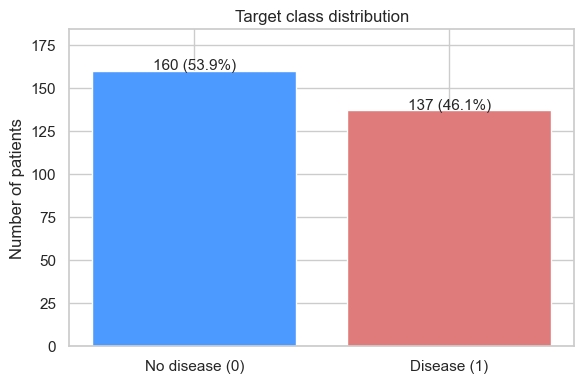

In [5]:
counts = heart_clean["target"].value_counts().sort_index()
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["No disease (0)", "Disease (1)"], counts, color=["#4C9AFF", "#E07B7B"])

for bar, n, p in zip(bars, counts, pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{n} ({p:.1f}%)", ha="center", fontsize=11)

ax.set_title("Target class distribution")
ax.set_ylabel("Number of patients")
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

## Continuous predictors vs. target

Compare the distribution of each continuous predictor between patients with and without disease. Boxplots show the visual separation; a two-sample t-test flags which differences are statistically significant.

### Observations

Four of the five continuous predictors differ significantly between groups (p < 0.01):

- **`thalach`** (max heart rate achieved): largest effect — diseased patients reach ~19 bpm lower peak heart rate on average (t = 7.93). The clearest visual separation.
- **`oldpeak`** (ST depression during exercise): diseased patients show ~1.0 unit higher values, with a much wider spread (t = -7.76).
- **`age`**: diseased patients are ~4 years older on average (t = -4.06).
- **`trestbps`** (resting BP): small but significant difference (~5 mmHg, p = 0.009).
- **`chol`** (cholesterol): no significant difference (p = 0.17), which is somewhat counterintuitive — worth flagging in the report.

**Takeaway.** `thalach` and `oldpeak` look like the strongest individual predictors and will likely carry the most weight in the logistic regression. The chol result is a useful caveat: a clinically famous risk factor isn't doing much work in this sample on its own.

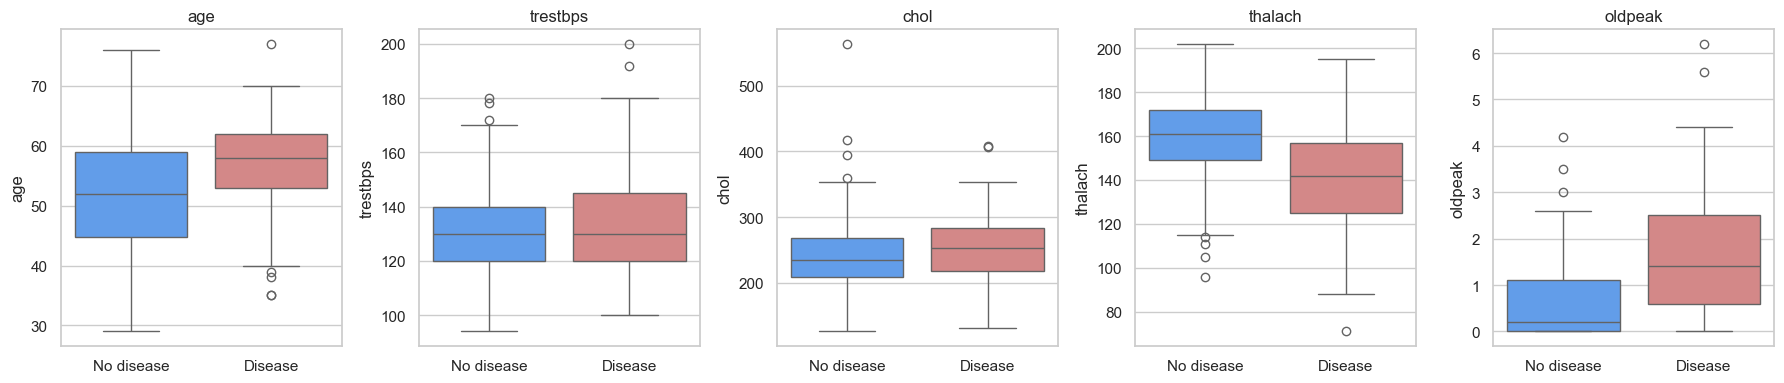

,variable,mean_no_disease,mean_disease,t,p_value
0,age,52.644,56.759,-4.064,0.000
1,trestbps,129.175,134.635,-2.639,0.009
2,chol,243.494,251.854,-1.392,0.165
3,thalach,158.581,139.109,7.929,0.000
4,oldpeak,0.599,1.589,-7.756,0.000


In [7]:
continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

results = []
for ax, col in zip(axes, continuous_cols):
    sns.boxplot(data=heart_clean, x="target", y=col, hue="target",
                palette=["#4C9AFF", "#E07B7B"], legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No disease", "Disease"])

    # Welch's t-test (doesn't assume equal variance)
    g0 = heart_clean.loc[heart_clean["target"] == 0, col]
    g1 = heart_clean.loc[heart_clean["target"] == 1, col]
    t, p = stats.ttest_ind(g0, g1, equal_var=False)
    results.append({"variable": col, "mean_no_disease": g0.mean(),
                    "mean_disease": g1.mean(), "t": t, "p_value": p})

plt.tight_layout()
plt.show()

pd.DataFrame(results).round(3)

## Categorical predictors vs. target

For each categorical predictor, show the disease rate within each category as a stacked bar plot. A chi-square test of independence flags which categoricals are significantly associated with the target.

### Observations

Seven of eight categorical predictors are significantly associated with the target. Ranked by chi-square strength:

- **`thal`** (thalassemia stress test result): the strongest single categorical — patients with values 6 (fixed defect) or 7 (reversible defect) have ~67–77% disease rate vs. ~23% for value 3 (normal).
- **`cp`** (chest pain type): striking gradient — type 4 (asymptomatic) shows ~73% disease rate, while types 1–3 are all under 35%. Counterintuitive on the surface, but consistent with the clinical literature: asymptomatic patients are often those with established disease being investigated.
- **`ca`** (number of major vessels colored by fluoroscopy): clear dose-response — disease rate climbs from ~25% at 0 vessels to ~85% at 3.
- **`exang`** (exercise-induced angina): patients who experience it have ~77% disease rate vs. ~32% who don't.
- **`slope`**, **`sex`**, **`restecg`**: all significant with moderate effects. Males show roughly twice the disease rate of females in this sample.
- **`fbs`** (fasting blood sugar > 120): the only non-significant predictor (p ≈ 1.0). Like cholesterol, a classic risk factor that doesn't carry signal here on its own.

**Takeaway.** The categorical predictors carry strong signal — `thal`, `cp`, and `ca` look like they may be the most informative variables in the entire dataset. Combined with `thalach` and `oldpeak` from the continuous side, we have a clear set of headline features for the logistic regression.

**Small-cell caveat.** Some categories (e.g., `restecg = 1`) have low counts, which can inflate chi-square. The conclusion is unlikely to change for the high-signal predictors, but the report should re-run borderline cases with Fisher's exact test.

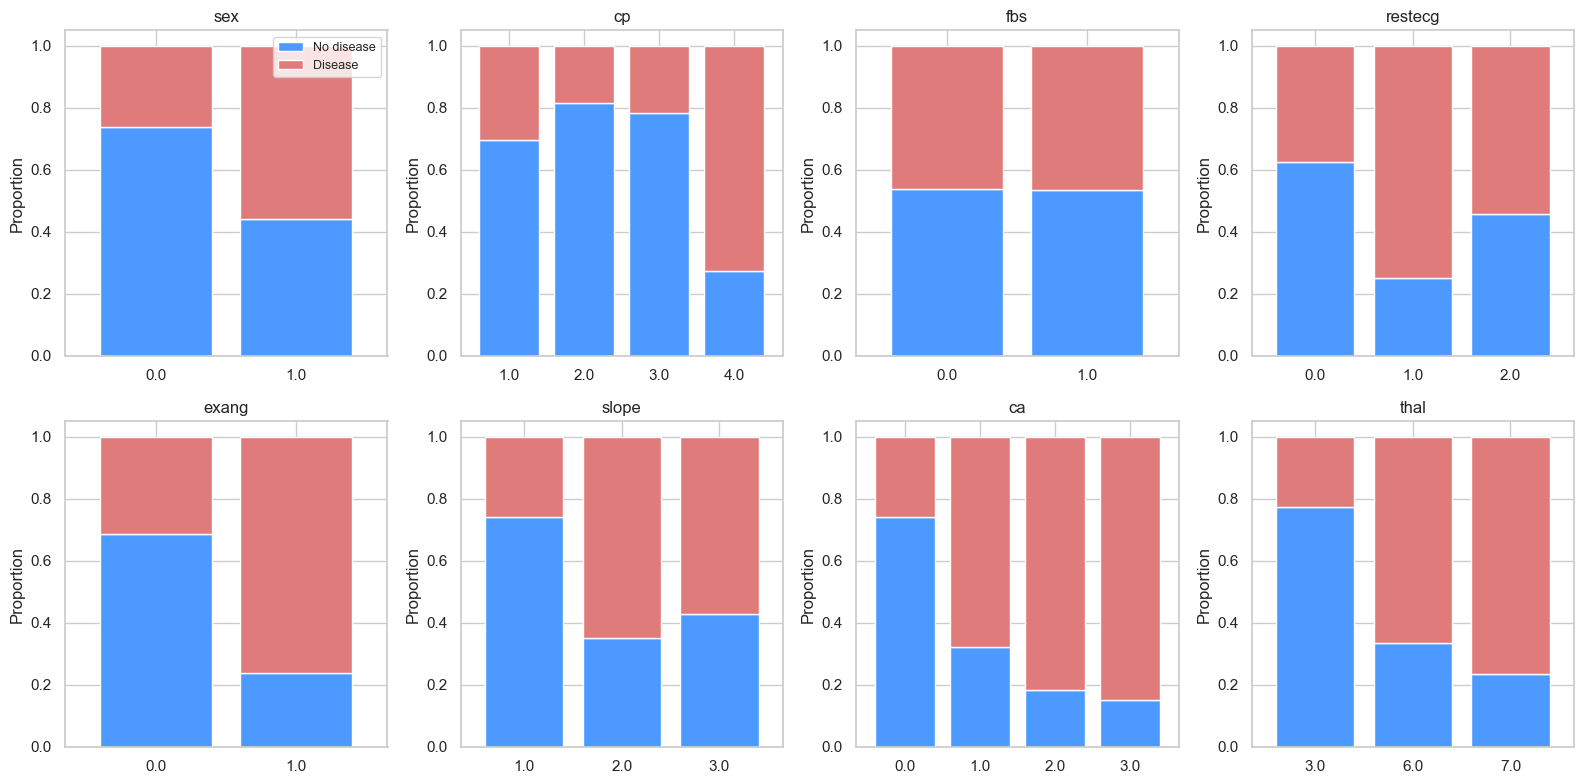

,variable,chi2,dof,p_value
7,thal,82.4601,2,0.0000
1,cp,77.2758,3,0.0000
6,ca,72.3005,3,0.0000
4,exang,50.9426,1,0.0000
5,slope,43.4732,2,0.0000
0,sex,21.8516,1,0.0000
3,restecg,9.5755,2,0.0083
2,fbs,0.0000,1,1.0000


In [8]:
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

results = []
for ax, col in zip(axes.flat, categorical_cols):
    # Proportions within each category, stacked
    ct = pd.crosstab(heart_clean[col], heart_clean["target"], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=ax,
            color=["#4C9AFF", "#E07B7B"], legend=False, width=0.8)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=0)

    # Chi-square test of independence on raw counts
    counts_table = pd.crosstab(heart_clean[col], heart_clean["target"])
    chi2, p, dof, _ = stats.chi2_contingency(counts_table)
    results.append({"variable": col, "chi2": chi2, "dof": dof, "p_value": p})

# One shared legend
axes.flat[0].legend(["No disease", "Disease"], loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

pd.DataFrame(results).sort_values("p_value").round(4)